# Customer Churn Prediction in Telecom Industry

Customer churn refers to when customers stop using a company's service.  
In the telecom industry, churn prediction is important because acquiring new customers is more expensive than retaining existing ones.

This project focuses on analyzing telecom customer data to understand the factors that influence churn and preparing the dataset for machine learning models.

## Importing Required Libraries

In this section, we import the necessary Python libraries used for data analysis and visualization.

- **Pandas** – Used for data manipulation and handling datasets.
- **NumPy** – Used for numerical operations.
- **Matplotlib** – Used for data visualization.
- **Seaborn** – Used for advanced statistical visualizations.
- **SciPy (zscore)** – Used for statistical analysis and outlier detection.

Warnings are also suppressed to keep the notebook output clean.

In [181]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
import warnings
warnings.filterwarnings('ignore')


## Loading the Dataset

The dataset is loaded using the Pandas `read_csv()` function.

This telecom dataset contains information about customers including:

- Customer demographics
- Services subscribed
- Billing details
- Contract type
- Payment method
- Churn status

After loading the dataset, it is stored in a dataframe for further analysis.

In [182]:
df = pd.read_csv('telco_data.csv') 

## Viewing the First Few Rows of the Dataset

The `head()` function is used to display the first five rows of the dataset.

This helps us quickly understand:
- The structure of the dataset
- Column names
- Data types
- Sample values

In [183]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1.0,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34.0,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2.0,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45.0,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2.0,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Output Explanation

The output displays the first five rows of the dataset. Each row represents a telecom customer and each column represents a feature describing that customer.

Some important columns observed:

- **customerID** – Unique ID assigned to each customer.
- **gender** – Gender of the customer (Male/Female).
- **SeniorCitizen** – Indicates whether the customer is a senior citizen (1 = Yes, 0 = No).
- **tenure** – Number of months the customer has stayed with the company.
- **InternetService** – Type of internet service used by the customer.
- **Contract** – Type of contract (Month-to-month, One year, Two year).
- **MonthlyCharges** – Amount charged to the customer every month.
- **TotalCharges** – Total amount charged during the customer’s tenure.
- **Churn** – Indicates whether the customer left the company (Yes/No).

This preview helps us understand the structure of the dataset and the type of information available.

## Checking Dataset Shape

The `shape` attribute shows the size of the dataset.

It returns two values:
- **Number of rows** – total customer records
- **Number of columns** – total features in the dataset

This helps us understand the dataset dimensions.

In [184]:
df.shape

(7043, 21)

### Output Explanation

The dataset contains **7043 rows and 21 columns**.

- **7043 rows** represent individual telecom customers.
- **21 columns** represent different features describing each customer.

This means the dataset contains information about **7043 customers with 21 attributes each**.

### null values

## Checking Missing Values

Missing values can negatively affect data analysis and machine learning models.

The `isnull().sum()` function is used to identify the number of missing values in each column of the dataset.

Handling missing data is an important step in data preprocessing.

In [185]:
df.isnull().sum()

customerID             0
gender               750
SeniorCitizen          0
Partner             1000
Dependents             0
tenure              2500
PhoneService           0
MultipleLines          0
InternetService     1000
OnlineSecurity         0
OnlineBackup           0
DeviceProtection       0
TechSupport            0
StreamingTV         1500
StreamingMovies        0
Contract               0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges      1500
TotalCharges           0
Churn                  0
dtype: int64

### Output Explanation

The output shows the number of missing values in each column of the dataset.

From the result we observe:

- Most columns do **not contain missing values**.
- Some columns such as **tenure, OnlineBackup, StreamingTV, StreamingMovies, and MonthlyCharges** contain missing values.

These missing values need to be handled during the **data preprocessing stage** to ensure accurate analysis and model performance.

## Statistical Summary of Numerical Features

The `describe()` function provides statistical details of numerical columns in the dataset.

It includes:
- Count
- Mean
- Standard deviation
- Minimum value
- Quartiles (25%, 50%, 75%)
- Maximum value

This helps understand the distribution of numerical features such as **tenure** and **monthly charges**.

In [186]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,4543.000000,5543.000000
mean,0.162147,32.546555,64.876403
std,0.368612,24.505519,30.101331
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.750000
50%,0.000000,29.000000,70.550000
75%,0.000000,56.000000,89.925000
max,1.000000,72.000000,118.600000


### Output Explanation

The output provides a statistical summary of the numerical columns in the dataset.

Key observations:

- **SeniorCitizen**
  - Mean value is around 0.16, indicating that only a small percentage of customers are senior citizens.

- **Tenure**
  - The average tenure is around 32 months.
  - Minimum tenure is 0 months and maximum tenure is 72 months.

- **MonthlyCharges**
  - The average monthly charge is around 64.76.
  - Charges range from approximately 18 to 118.

This summary helps us understand the distribution and range of important numerical features in the dataset.

### Inspecting Dataset Structure

In this step, we use `df.info()` to examine the structure of the dataset.

This function helps us understand:
- Total number of rows and columns
- Column names
- Data types of each column
- Number of non-null values
- Memory usage

This information helps identify missing values and incorrect data types that need to be fixed during data cleaning.

In [187]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            6293 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           6043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            4543 non-null   float64
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   6043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       5543 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Output Interpretation

The dataset contains **7043 rows and 21 columns**.

From the output we observe:

- Some columns contain missing values because their **non-null count is less than 7043**.
- The dataset contains three data types:
  - **object** – categorical values such as gender, contract type, internet service.
  - **int64** – integer numeric values such as SeniorCitizen.
  - **float64** – decimal numeric values such as tenure and MonthlyCharges.

These observations help identify which columns require **data cleaning and preprocessing**.

### Converting TotalCharges to Numeric Format

The `TotalCharges` column is currently stored as a text (object) data type.

Since this column represents numerical values, we convert it into a numeric format using `pd.to_numeric()`.

The parameter `errors='coerce'` converts invalid values into `NaN`, allowing them to be handled later during missing value treatment.

In [188]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(df['TotalCharges'].dtypes)

float64


### Output Interpretation

The output shows that the data type of `TotalCharges` is now **float64**.

This confirms that the column has been successfully converted into a numeric format, allowing it to be used in calculations, statistical analysis, and machine learning models.

## Week 3 – Data Cleaning Phase

In this stage, we handle missing values in the dataset.

The dataset contains both **numerical and categorical features**, so different imputation strategies are used:

- **Numerical columns** → Missing values are replaced with the **median**.
- **Categorical columns** → Missing values are replaced with the **mode (most frequent value)**.

This ensures the dataset becomes complete and suitable for further analysis.

### Handling Missing Values in Numerical Columns

First, we identify all numerical columns in the dataset using `select_dtypes()`.

For each numerical column, missing values are replaced with the **median value** of that column.

The median is used because it is less affected by extreme values compared to the mean.

In [189]:
numerical_cols = df.select_dtypes(include=np.number).columns

for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)


### Handling Missing Values in Categorical Columns

Next, we identify categorical columns using `select_dtypes(include='object')`.

Missing values in these columns are replaced using the **mode**, which represents the most frequently occurring value in the column.

In [190]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)


### Verifying Missing Values

After performing the imputation process, we check the dataset again to confirm that all missing values have been handled.

The `isnull().sum()` function is used to count remaining missing values in each column.

In [191]:
print(df.isnull().sum())


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


### Output Interpretation

The output shows **0 missing values for all columns** in the dataset.

This confirms that the data cleaning process was successful and the dataset is now complete.  
The dataset is ready for further steps such as **outlier detection, feature engineering, and machine learning model building**.

### Converting SeniorCitizen to Categorical Data

The `SeniorCitizen` column currently contains numerical values (0 and 1).  
However, this column actually represents a **categorical feature**:

- 0 → Not a senior citizen
- 1 → Senior citizen

Therefore, we convert the column from numeric type to **object (categorical) type** using `astype("object")`.  
This helps ensure the feature is treated correctly during analysis and modeling.

In [192]:
print(df['SeniorCitizen'].astype('object'))

0       0
1       0
2       0
3       0
4       0
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: SeniorCitizen, Length: 7043, dtype: object


### Output Interpretation

The output shows the values of the `SeniorCitizen` column after conversion.

- The column now has **object data type**, meaning it is treated as a categorical variable.
- The length of the column is **7043**, which matches the total number of customers in the dataset.

This confirms the conversion was successful and the column can now be used as a categorical feature.

### Boxplot Visualization for MonthlyCharges and Tenure

A boxplot is used to visualize the distribution of numerical data and detect potential outliers.

In this step, we create boxplots for two important numerical features:

- **MonthlyCharges** – the amount a customer pays per month
- **tenure** – the number of months the customer has stayed with the company

This visualization helps us understand the spread of the data and identify extreme values.

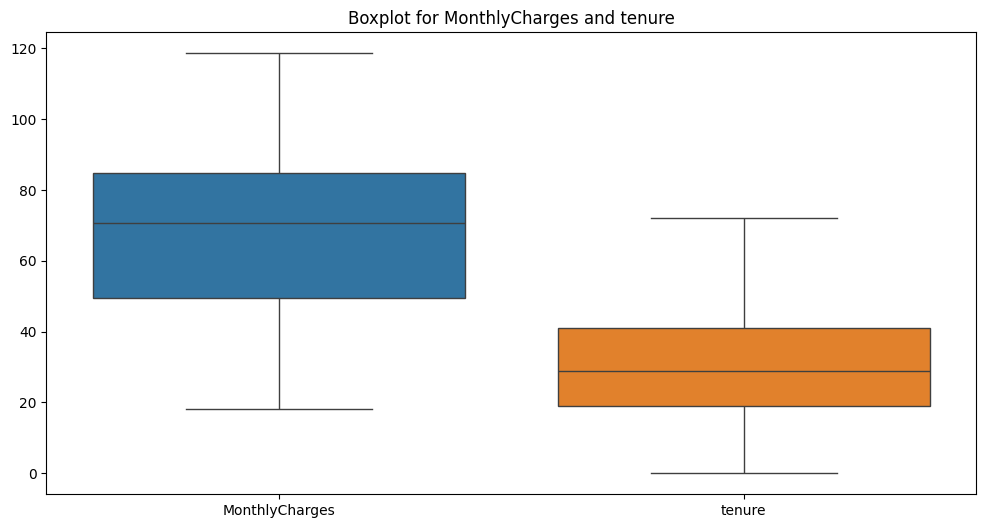

In [193]:
plt.figure(figsize=(12,6))

sns.boxplot(df[['MonthlyCharges','tenure']])

plt.title("Boxplot for MonthlyCharges and tenure")

plt.show()


### Output Interpretation

The boxplots show the distribution of **MonthlyCharges** and **tenure**.

Observations:

- **MonthlyCharges**
  - Values range approximately from **18 to 120**.
  - Most customers pay between **50 and 90 per month**.
  - Some higher values may indicate potential outliers.

- **Tenure**
  - Values range from **0 to around 72 months**.
  - Many customers stay with the company for **20 to 40 months**.

The boxplot helps visually detect whether extreme values (outliers) exist in these variables.

### Boxplot for MonthlyCharges

To analyze the distribution of monthly charges in more detail, we create a separate boxplot for the `MonthlyCharges` column.

This helps us clearly observe:
- The median monthly charge
- The range of charges
- Potential outliers in customer billing.

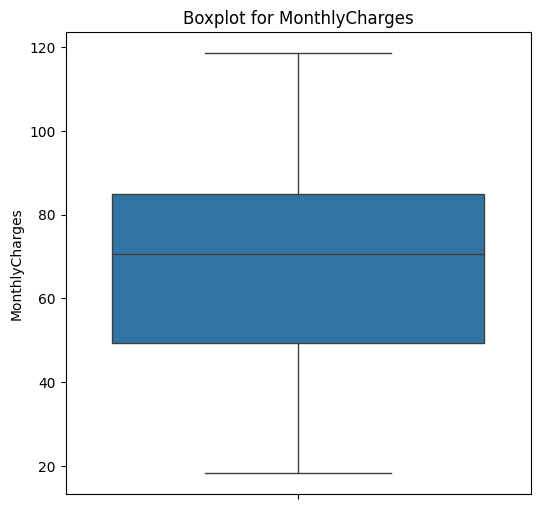

In [194]:
plt.figure(figsize=(6,6))
sns.boxplot(df['MonthlyCharges'])
plt.title("Boxplot for MonthlyCharges")
plt.show()

### Output Interpretation

The boxplot shows the distribution of **MonthlyCharges** among customers.

Key observations:

- The **median monthly charge** is around **70**.
- Most customers pay between **50 and 90** per month.
- The minimum charge is around **18**, while the maximum is close to **120**.

This visualization helps understand how customer billing is distributed across the dataset.

In [195]:
column = ['MonthlyCharges','tenure','TotalCharges']


### Outlier Detection using Z-Score

To detect outliers statistically, we use the **Z-score method**.

The Z-score measures how far a data point is from the mean in terms of standard deviations.

In this step, we calculate Z-scores for the following numerical columns:

- MonthlyCharges
- tenure
- TotalCharges

Values with very high or very low Z-scores may indicate potential outliers.

In [196]:
df_zscore = df[column].apply(zscore)
print(df_zscore.head(10))




   MonthlyCharges    tenure  TotalCharges
0       -1.351911 -1.533375     -0.994242
1       -0.340816  0.137318     -0.173244
2       -0.456476 -1.482748     -0.959674
3       -0.887404  0.694215     -0.194766
4        0.172194 -1.482748     -0.940470
5        1.252312 -1.178985     -0.645186
6        0.858694 -0.470207     -0.146799
7       -1.355642 -1.077731     -0.874137
8        0.166598 -0.115818      0.337349
9       -0.370663  1.554875      0.532439


### Output Interpretation

The output displays the first few rows of calculated Z-scores for the selected numerical columns.

Each value represents how many standard deviations the observation is from the mean.

- A **Z-score close to 0** indicates the value is near the average.
- Larger positive or negative values indicate that the data point is farther from the mean.

These values can be used to identify extreme observations that may represent outliers.

In [197]:
outliers = df[(df_zscore.abs() > 3).any(axis=1)]

print("Number of outliers:", len(outliers))


Number of outliers: 0


### we dont have outlier in the dataset

## Week 4 – Exploratory Data Analysis (EDA)

In this stage, we perform **Exploratory Data Analysis (EDA)** to better understand the dataset.

EDA helps identify patterns, relationships, and trends in the data through visualizations.

In this section, we analyze:
- Customer churn distribution
- Demographic features such as gender and senior citizen status
- Customer relationship features such as partner and dependents

### Churn Distribution Analysis

In this step, we analyze how many customers have **churned (left the company)** and how many customers have **remained**.

A **pie chart** is used to visualize the proportion of churned and non-churned customers in the dataset.

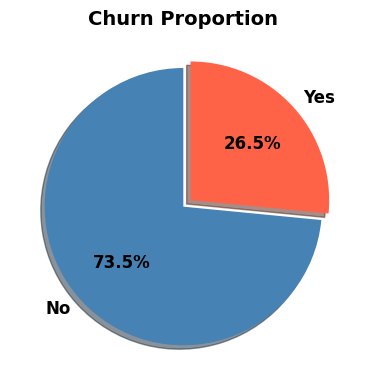

In [198]:
import matplotlib.pyplot as plt

churn_counts = df['Churn'].value_counts()

plt.figure(figsize=(4,4))

plt.pie(
    churn_counts.values,
    labels=churn_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['steelblue', 'tomato'],
    explode=(0, 0.07),
    shadow=True,
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)

plt.title('Churn Proportion', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Output Interpretation

The pie chart shows the distribution of customer churn.

Observations:

- **73.5% of customers did not churn**, meaning they continued using the telecom service.
- **26.5% of customers churned**, meaning they stopped using the service.

This indicates that the majority of customers remain with the company, but a significant portion still leaves, which makes churn prediction an important problem.

### Customer Demographic Analysis

In this step, we visualize several demographic features of customers using **count plots**.

The following variables are analyzed:

- **SeniorCitizen** – whether the customer is a senior citizen
- **Gender** – male or female
- **Partner** – whether the customer has a partner
- **Dependents** – whether the customer has dependents

These visualizations help understand the composition of the customer base.

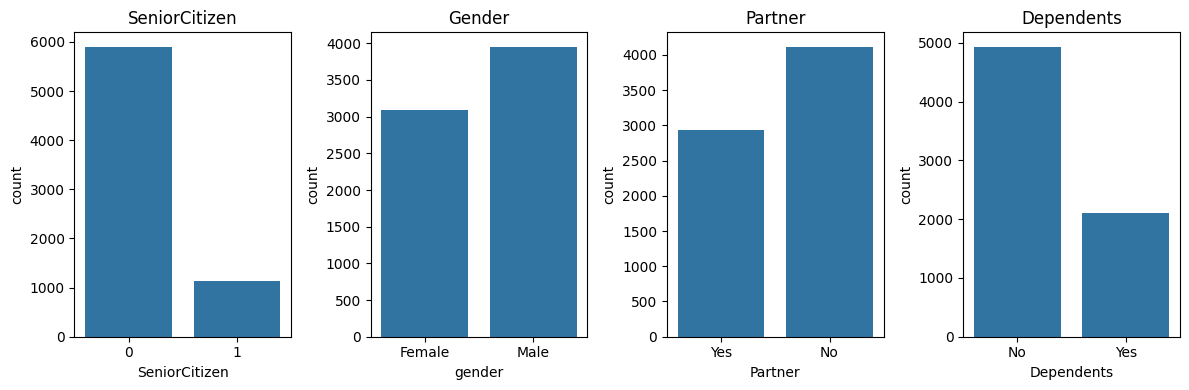

In [199]:
plt.figure(figsize=(12,4))

# SeniorCitizen
plt.subplot(1,4,1)
sns.countplot(x='SeniorCitizen', data=df)
plt.title("SeniorCitizen")

# Gender
plt.subplot(1,4,2)
sns.countplot(x='gender', data=df)
plt.title("Gender")

# Partner
plt.subplot(1,4,3)
sns.countplot(x='Partner', data=df)
plt.title("Partner")

plt.subplot(1,4,4)
sns.countplot(x='Dependents', data=df)
plt.title("Dependents")



plt.tight_layout()
plt.show()

### Output Interpretation

The count plots show the distribution of different customer demographic features.

Key observations:

- **SeniorCitizen**
  - Most customers are **not senior citizens**, while a smaller portion are senior citizens.

- **Gender**
  - The dataset contains a relatively balanced number of **male and female customers**.

- **Partner**
  - A large number of customers **do not have partners**, while many others do.

- **Dependents**
  - Most customers **do not have dependents**, with fewer customers having dependents.

These insights help understand the characteristics of customers in the telecom dataset.

### Churn Analysis Based on Gender

In this step, we analyze how customer churn varies based on **gender**.

A **count plot** is used to compare the number of churned and non-churned customers for each gender category (Male and Female).

This helps identify whether gender has any noticeable influence on customer churn.

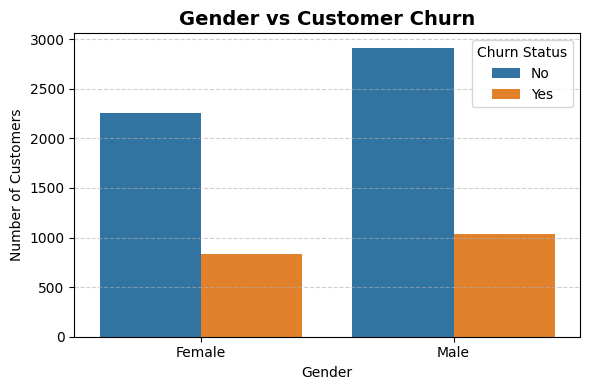

In [200]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='gender',
    hue='Churn',
    data=df
)

plt.title("Gender vs Customer Churn", fontsize=14, fontweight='bold')
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.legend(title="Churn Status")
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Output Interpretation

The count plot shows the distribution of churn across male and female customers.

Observations:

- Both **male and female customers show similar churn patterns**.
- The number of customers who **did not churn is higher** for both genders.
- Although male customers appear slightly higher in number overall, the **churn proportion between genders is relatively similar**.

This suggests that **gender alone may not be a strong factor influencing customer churn**.

### Churn Analysis Based on Partner Status

In this step, we examine whether having a **partner** influences customer churn.

A count plot is created to compare churn distribution between:
- Customers who **have a partner**
- Customers who **do not have a partner**

This helps determine whether relationship status affects customer retention.

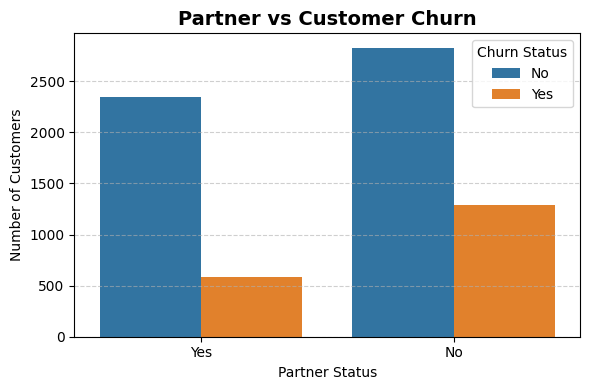

In [201]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Partner',
    hue='Churn',
    data=df
)

plt.title("Partner vs Customer Churn", fontsize=14, fontweight='bold')
plt.xlabel("Partner Status")
plt.ylabel("Number of Customers")

plt.legend(title="Churn Status")
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Output Interpretation

The count plot shows the churn distribution for customers with and without partners.

Observations:

- Customers **without partners show a higher number of churn cases**.
- Customers **with partners tend to stay longer with the service**.
- In both groups, the number of **non-churned customers is higher than churned customers**.

This suggests that customers with partners may have **greater service stability and lower churn probability**.

### Churn Analysis Based on Tenure

In this step, we analyze how **customer tenure (number of months with the company)** relates to churn.

A histogram is used to visualize the distribution of tenure values for churned and non-churned customers.

This helps identify whether customers with shorter or longer service durations are more likely to churn.

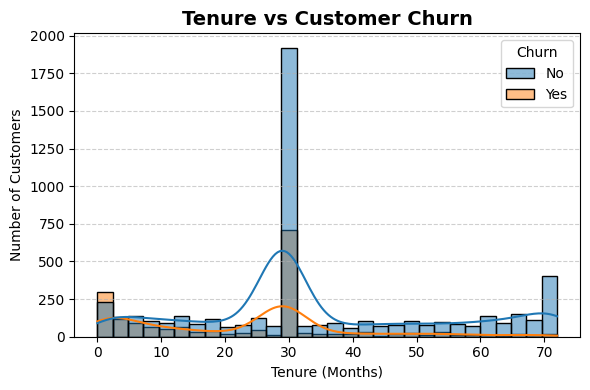

In [202]:
plt.figure(figsize=(6,4))

sns.histplot(
    data=df,
    x='tenure',
    hue='Churn',
    bins=30,
    kde=True
)

plt.title("Tenure vs Customer Churn", fontsize=14, fontweight='bold')
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Output Interpretation

The histogram shows the relationship between customer tenure and churn.

Key observations:

- Customers with **shorter tenure (new customers)** tend to churn more frequently.
- Customers with **longer tenure are more likely to remain with the company**.
- This indicates that customers who stay longer with the service develop stronger loyalty.

Therefore, tenure appears to be an **important factor influencing customer churn behavior**.

### Churn Analysis Based on Monthly Charges

In this step, we analyze how **monthly charges influence customer churn**.

A histogram with a density curve is used to visualize the distribution of **MonthlyCharges** for customers who churned and those who did not.

This helps identify whether customers with higher monthly charges are more likely to leave the service.

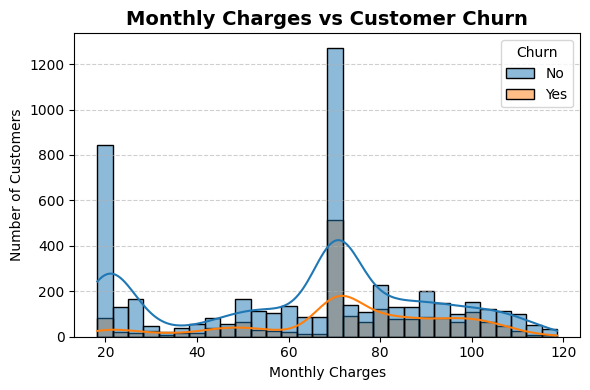

In [203]:
plt.figure(figsize=(6,4))

sns.histplot(
    data=df,
    x='MonthlyCharges',
    hue='Churn',
    bins=30,
    kde=True
)

plt.title("Monthly Charges vs Customer Churn", fontsize=14, fontweight='bold')
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Output Interpretation

The histogram shows the distribution of monthly charges for churned and non-churned customers.

Observations:

- Most customers pay between **60 and 90 units per month**.
- Customers with **higher monthly charges tend to have slightly higher churn rates**.
- A large number of customers with moderate monthly charges remain with the service.

This suggests that **pricing may influence churn behavior**, especially for customers paying higher monthly fees.

### Churn Analysis Based on Total Charges

In this step, we examine the relationship between **TotalCharges and customer churn**.

A histogram with KDE is used to visualize the distribution of total charges among churned and non-churned customers.

TotalCharges represent the overall amount a customer has paid during their entire tenure with the company.

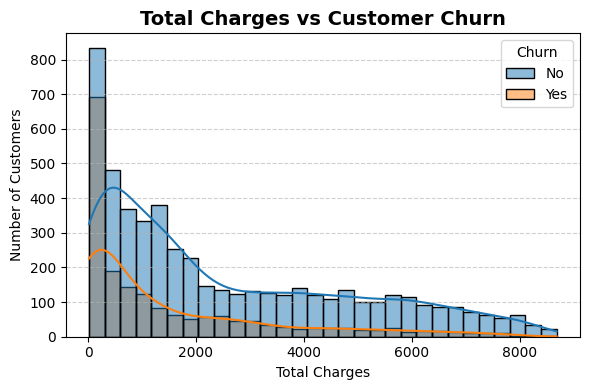

In [204]:
plt.figure(figsize=(6,4))

sns.histplot(
    data=df,
    x='TotalCharges',
    hue='Churn',
    bins=30,
    kde=True
)

plt.title("Total Charges vs Customer Churn", fontsize=14, fontweight='bold')
plt.xlabel("Total Charges")
plt.ylabel("Number of Customers")

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Output Interpretation

The histogram shows how total charges are distributed among customers.

Observations:

- Many customers have **lower total charges**, which typically indicates **shorter tenure**.
- Customers with **lower total charges show a higher churn rate**.
- Customers with **higher total charges generally remain with the company**, indicating longer customer relationships.

This suggests that customers who stay longer with the service tend to generate higher total revenue and are less likely to churn.

### Analysis of Senior Citizens by Gender

In this step, we analyze the distribution of **senior citizen customers across genders**.

A count plot is used to visualize how many male and female customers fall into the senior citizen and non-senior citizen categories.

This helps understand the demographic composition of the dataset.

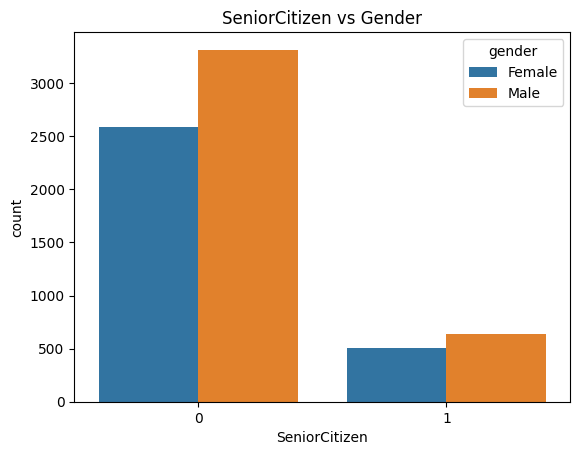

In [205]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='SeniorCitizen', hue='gender', data=df)

plt.title("SeniorCitizen vs Gender")
plt.show()

### Output Interpretation

The count plot shows the distribution of senior citizens based on gender.

Observations:

- Most customers in the dataset are **not senior citizens (value 0)**.
- Among both genders, the number of **non-senior customers is significantly higher** than senior customers.
- Male customers appear slightly more frequent than female customers in both categories.

This visualization helps understand the **age-related demographic structure** of the telecom customer base.

### Relationship Between Gender and Dependents

In this step, we analyze how the **gender of customers relates to whether they have dependents**.

A count plot is used to visualize the number of male and female customers who have dependents and those who do not.

This helps understand the demographic characteristics of customers in the dataset.

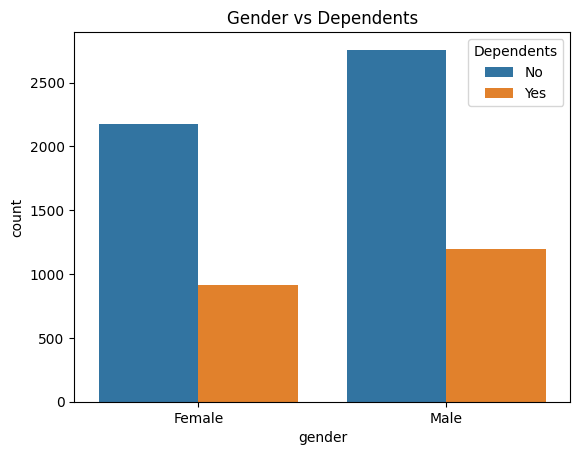

In [206]:
sns.countplot(x='gender', hue='Dependents', data=df)

plt.title("Gender vs Dependents")
plt.show()

### Output Interpretation

The count plot shows the distribution of dependents across male and female customers.

Observations:

- Most customers **do not have dependents**.
- Both male and female customers show similar patterns regarding dependents.
- Male customers appear slightly higher in number compared to female customers.

This visualization helps understand the family-related characteristics of the customer base.

### Converting Churn to Numeric Values

The `Churn` column currently contains categorical values such as **Yes** and **No**.

For correlation analysis and machine learning models, it is useful to convert these values into numeric form.

Therefore:
- **Yes → 1**
- **No → 0**

This transformation allows the churn variable to be used in numerical calculations.

In [207]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [208]:
num_df = df.select_dtypes(include=['int64', 'float64'])

In [209]:
corr_matrix = num_df.corr()

print(corr_matrix)

                SeniorCitizen    tenure  MonthlyCharges  TotalCharges  \
SeniorCitizen        1.000000  0.004008        0.192526      0.102652   
tenure               0.004008  1.000000        0.221251      0.661536   
MonthlyCharges       0.192526  0.221251        1.000000      0.575482   
TotalCharges         0.102652  0.661536        0.575482      1.000000   
Churn                0.150889 -0.269223        0.167804     -0.199037   

                   Churn  
SeniorCitizen   0.150889  
tenure         -0.269223  
MonthlyCharges  0.167804  
TotalCharges   -0.199037  
Churn           1.000000  


### Output Interpretation

The churn column has been successfully converted into numeric format.

- Value **1** represents customers who have churned.
- Value **0** represents customers who have not churned.

This numeric representation allows churn to be included in correlation analysis and machine learning models.

### Visualizing Correlations Using a Heatmap

To better understand the relationships between numerical variables, a **heatmap visualization** is created.

A heatmap displays correlation values using colors, making it easier to identify strong positive or negative relationships between variables.

### Calculating Correlation Between Numerical Features

In this step, we analyze the relationship between numerical variables in the dataset.

First, numerical columns such as:
- SeniorCitizen
- tenure
- MonthlyCharges
- TotalCharges
- Churn

are selected.

Then, a **correlation matrix** is calculated to measure how strongly these variables are related to each other.


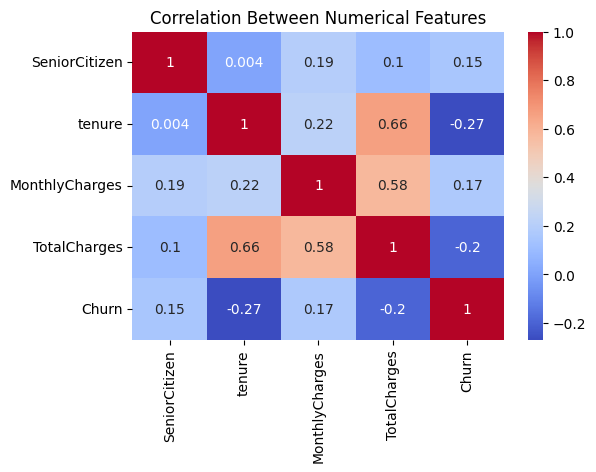

In [210]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Between Numerical Features")
plt.show()

### Output Interpretation

The printed table represents the **correlation matrix** between numerical variables.

Correlation values range between **-1 and 1**:

- **1** → Strong positive relationship
- **-1** → Strong negative relationship
- **0** → No relationship

From the table we observe:

- **tenure and TotalCharges show a strong positive correlation**, meaning customers who stay longer accumulate higher total charges.
- **MonthlyCharges has a moderate positive correlation with TotalCharges**.
- **Churn has a negative correlation with tenure**, indicating customers with shorter tenure are more likely to churn.

The heatmap visually represents the correlation between numerical features.

Key insights:

- **Tenure and TotalCharges show the strongest positive correlation**, indicating long-term customers pay higher total charges.
- **MonthlyCharges also positively correlates with TotalCharges**.
- **Churn shows a negative correlation with tenure**, meaning customers who stay longer are less likely to churn.

These insights help identify which features may influence customer churn and are useful for building predictive models.
